# **Huwag KuKURAP: Probing Public Records with Data Science**

# Welcome to **Huwag KuKURAP**
---

### **UP Data Science Society's 2026 ACLE Workshop**
**"Huwag KuKURAP: Probing Public Records with Data Science"**

---

> This notebook is the official teaching material for the **UP Data Science Society's 2026 ACLE Workshop: "Huwag KuKURAP: Probing Public Records with Data Science."** Designed as a crash course in investigative data analytics, this workshop teaches you how to bypass political rhetoric and go straight to the data. You will learn to extract and analyze public records, uncover patterns of possible government corruption, and use data literacy as a weapon for a more transparent future.

---

| | |
| :--- | :--- |
| **Dataset** | [Open Data Portal by BetterGov.ph](https://data.bettergov.ph/datasets/5) |
| **Prepared by** | **Jess Vincent Ybut** |
| | *Director, Education and Research Committee* |

---

# Environment Setup

First, we need to bring in our tools. In Data Science, we use "libraries" which are collections of pre-written code.

* **Pandas**: Our "Excel on steroids" for handling tables.

* **Matplotlib/Seaborn**: For creating charts and graphs.


In [1]:
# Import the tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from google.colab import drive

In [2]:
# Mount GDrive
drive.mount('/content/drive')
rt_dir = '/content/drive/MyDrive/ACLE Materials'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading the Dataset

Next, we load our dataset. Public records come in various formats, such as CSV, Excel, and PDF. Depending on the file type and data quality, preprocessing may be required before we can begin our analysis.

In [3]:
file_path = rt_dir + '/Datasets/philgeps.parquet'
philgeps_df = pd.read_parquet(file_path)

In [4]:
philgeps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5481161 entries, 0 to 5481160
Data columns (total 12 columns):
 #   Column             Dtype         
---  ------             -----         
 0   id                 object        
 1   reference_id       object        
 2   contract_no        object        
 3   award_title        object        
 4   notice_title       object        
 5   awardee_name       object        
 6   organization_name  object        
 7   area_of_delivery   object        
 8   business_category  object        
 9   contract_amount    float64       
 10  award_date         datetime64[us]
 11  award_status       object        
dtypes: datetime64[us](1), float64(1), object(10)
memory usage: 501.8+ MB


## Quick Overview

In [5]:
print("--- DataFrame Info ---")
philgeps_df.info()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5481161 entries, 0 to 5481160
Data columns (total 12 columns):
 #   Column             Dtype         
---  ------             -----         
 0   id                 object        
 1   reference_id       object        
 2   contract_no        object        
 3   award_title        object        
 4   notice_title       object        
 5   awardee_name       object        
 6   organization_name  object        
 7   area_of_delivery   object        
 8   business_category  object        
 9   contract_amount    float64       
 10  award_date         datetime64[us]
 11  award_status       object        
dtypes: datetime64[us](1), float64(1), object(10)
memory usage: 501.8+ MB


In [6]:
print("\n--- DataFrame Dimensions (Rows, Columns) ---")
print(philgeps_df.shape)


--- DataFrame Dimensions (Rows, Columns) ---
(5481161, 12)


In [7]:
print("\n--- Number of NaN Values per Column ---")
display(philgeps_df.isnull().sum())


--- Number of NaN Values per Column ---


,0
id,0
reference_id,1900922
contract_no,1900922
award_title,146
notice_title,688
awardee_name,0
organization_name,0
area_of_delivery,464947
business_category,0
contract_amount,0


In [8]:
print("\n--- Descriptive Statistics ---")
display(philgeps_df.describe())


--- Descriptive Statistics ---


,contract_amount,award_date
count,5.481161e+06,5481160
mean,3.071312e+06,2020-02-21 15:05:42.379331
min,1.000000e-02,1920-01-08 00:00:00
25%,3.973200e+04,2017-05-24 00:00:00
50%,1.456945e+05,2021-02-15 00:00:00
75%,6.996460e+05,2023-08-30 00:00:00
max,1.417929e+11,2034-10-04 00:00:00
std,7.530301e+07,NaN


## Some Column Values

In [9]:
columns_to_check = [
    'awardee_name',
    'organization_name',
    'area_of_delivery',
    'business_category'
]

for col in columns_to_check:
    unique_values = philgeps_df[col].unique()
    print(f"Unique values for '{col}' ({len(unique_values)} total):")
    display(unique_values[:10])


Unique values for 'awardee_name' (127049 total):


array(['MA-AN OFFICE AND SCHOOL SUPPLIES', 'KAWA RESORT',
       'PAZ PETRON SUPER STATION CORPORATION',
       'EXECOM COMPUTER SALES & SERVICES', "GINO'S MARKETING",
       'RUSTER MARKETING', 'DEX INTERNATIONAL CO.',
       'HEALTHSETH MEDICAL SOLUTIONS,INC.', 'MFR MARKETING',
       'BABY SHOBE TRADING CORP.'], dtype=object)

Unique values for 'organization_name' (24465 total):


array(['PROVINCE OF COTABATO',
       'DEPARTMENT OF SOCIAL WELFARE AND DEVELOPMENT - CARAGA',
       'MINES AND GEOSCIENCES BUREAU - CARAGA',
       'DEPARTMENT OF AGRICULTURE - REGION XI', 'PROVINCE OF MARINDUQUE',
       'DEPARTMENT OF EDUCATION - DIVISION OF CAPIZ',
       'LAND REGISTRATION AUTHORITY', 'ZAMBOANGA CITY MEDICAL CENTER',
       'DEPARTMENT OF EDUCATION - DIVISION OF LA CARLOTA CITY',
       'PAMANTASAN NG LUNGSOD NG MAYNILA'], dtype=object)

Unique values for 'area_of_delivery' (526 total):


array(['Cotabato', 'Surigao Del Norte', None, 'Marinduque', 'Capiz',
       'Metro Manila', 'Zamboanga Del Sur', 'Negros Occidental',
       'Pampanga', 'Quezon'], dtype=object)

Unique values for 'business_category' (170 total):


array(['Office Equipment', 'Catering Services',
       'Fuels/Fuel Additives & Lubricants & Anti Corrosive',
       'Information Technology', 'Drugs and Medicines', 'Food Stuff',
       'Construction Projects',
       'Medical Supplies and Laboratory Instrument',
       'Office Equipment Supplies and Consumables', 'General Merchandise'],
      dtype=object)

# Cleaning the Features

Raw data is often "messy." Before analyzing, we must:

* **Convert Dates**: Ensure the computer knows '2023-01-01' is a date, not just text.

* **Standardize Names**: Convert everything to lowercase so "COMPANY A" and "company a" are treated as the same entity.

In [10]:
# Convert award_date to a proper date format
philgeps_df['award_date'] = pd.to_datetime(philgeps_df['award_date'], errors='coerce')

# Lowercase organization, awardee names, area of delivery, and business category for consistency
philgeps_df['organization_name'] = philgeps_df['organization_name'].str.lower()
philgeps_df['awardee_name'] = philgeps_df['awardee_name'].str.lower()
philgeps_df['area_of_delivery'] = philgeps_df['area_of_delivery'].str.lower()
philgeps_df['business_category'] = philgeps_df['business_category'].str.lower()

# Filter out rows with missing dates or zero-value contracts
philgeps_df = philgeps_df.dropna(subset=['award_date'])
philgeps_df = philgeps_df[philgeps_df['contract_amount'] > 0]

In [11]:
philgeps_df.head(5)

,id,reference_id,contract_no,award_title,notice_title,awardee_name,organization_name,area_of_delivery,business_category,contract_amount,award_date,award_status
0,b'\x12\x87\xd3\xbd\x08\x01G\xab\xb1\xa5\xa3X\x...,241011,241011,SVP-24-1456 Supply and Delivery of Various Equ...,SVP-24-1456 Supply and Delivery of Various Equ...,ma-an office and school supplies,province of cotabato,cotabato,office equipment,249750.0,2034-10-04,active
1,b'T\x0e!Y\x06\xcdC]\x88!\x07\xbd\xfc2\xb0K',None,None,CATERING SERVICES,Stress Management cum Team Building Workshop f...,kawa resort,department of social welfare and development -...,surigao del norte,catering services,183600.0,2033-11-08,active
2,b'}x\xfc0\xee\xe0Ms\xa9\x11\xc8\x7f6\x8d\xc5\xb9',2023-01-007,2023-01-007,Gasoline,2022-11-267,paz petron super station corporation,mines and geosciences bureau - caraga,surigao del norte,fuels/fuel additives & lubricants & anti corro...,710.0,2033-01-12,active
3,"b'\xf3X\xd9b\xcabDn\xaeqh,\xd2\x89\xa8\xa0'",2024-12-100,2024-12-100,Information Technology,MIADP-RPCOXI-079-2024-PROCUREMENT OF VARIOUS I...,execom computer sales & services,department of agriculture - region xi,None,information technology,140000.0,2026-12-11,active
4,b'h\xce[\xe6\xb9\xe8N\xbd\xa1\xe7\x8f_\x1fr!\xc0',None,None,Plain 0.9 NSS 1000ml,Supply and delivery of Drugs and Medicines for...,gino's marketing,province of marinduque,marinduque,drugs and medicines,453460.0,2026-12-05,active


# Analysis

## Top Contractors

In [12]:
def get_top_awardees(df, top_n=10, metric='amount',
                     organization_names=None,
                     awardee_names=None,
                     business_categories=None,
                     areas_of_delivery=None,
                     start_date=None,
                     end_date=None):
    """
    Identifies and visualizes the top awardees in the dataset based on filters.

    Args:
        df (pd.DataFrame): The PhilGEPS dataset (philgeps_df).
        top_n (int): The number of top companies to display in the chart. Default is 10.
        metric (str): The measurement used for ranking.
                      Use 'amount' for Total Contract Value (PHP).
                      Use 'counts' for Frequency (Number of awards won).
        organization_names (list, optional): Filter by specific government agencies.
        awardee_names (list, optional): Filter by specific private companies/suppliers.
        business_categories (list, optional): Filter by the type of industry (e.g., 'construction projects').
        areas_of_delivery (list, optional): Filter by the location where the project was delivered.
        start_date (str, optional): The beginning of the time period (format: 'YYYY-MM-DD').
        end_date (str, optional): The end of the time period (format: 'YYYY-MM-DD').

    Returns:
        pd.DataFrame: A table containing the awardee names, their win counts, and total amounts.
    """
    filtered_df = df.copy()

    # Filter by Date Span
    if start_date:
        filtered_df = filtered_df[filtered_df['award_date'] >= pd.to_datetime(start_date)]
    if end_date:
        filtered_df = filtered_df[filtered_df['award_date'] <= pd.to_datetime(end_date)]

    # Filter by Lists
    if organization_names:
        lower_orgs = [name.lower() for name in organization_names]
        filtered_df = filtered_df[filtered_df['organization_name'].isin(lower_orgs)]

    if awardee_names:
        lower_awardees = [name.lower() for name in awardee_names]
        filtered_df = filtered_df[filtered_df['awardee_name'].isin(lower_awardees)]

    if business_categories:
        lower_cats = [cat.lower() for cat in business_categories]
        filtered_df = filtered_df[filtered_df['business_category'].isin(lower_cats)]

    if areas_of_delivery:
        lower_areas = [area.lower() for area in areas_of_delivery]
        filtered_df = filtered_df[filtered_df['area_of_delivery'].isin(lower_areas)]

    # Check if we have data left after filtering
    if filtered_df.empty:
        print("No data found for those filters. Check your spelling or category names!")
        return None

    # Aggregation
    summary = filtered_df.groupby('awardee_name')['contract_amount'].agg(['count', 'sum']).reset_index()
    summary.columns = ['awardee_name', 'counts', 'amount']

    # Sorting & Visualization based on choice
    if metric == 'counts':
        top_list = summary.sort_values(by='counts', ascending=False).head(top_n)
        color_palette = 'viridis'
        title_label = "Frequency (Number of Awards)"
        x_axis = 'counts'
    else: # Default to amount
        top_list = summary.sort_values(by='amount', ascending=False).head(top_n)
        color_palette = 'magma'
        title_label = "Total Amount (PHP)"
        x_axis = 'amount'

    # Metadata for Title
    date_min = filtered_df['award_date'].min().strftime('%Y-%m-%d') if not filtered_df.empty else "N/A"
    date_max = filtered_df['award_date'].max().strftime('%Y-%m-%d') if not filtered_df.empty else "N/A"

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_list, x=x_axis, y='awardee_name', hue='awardee_name', palette=color_palette, legend=False)

    plt.title(f"Top {top_n} Awardees by {title_label}\nSpan: {date_min} to {date_max}", fontsize=14)
    plt.xlabel(title_label)
    plt.ylabel("Awardee Name")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return top_list

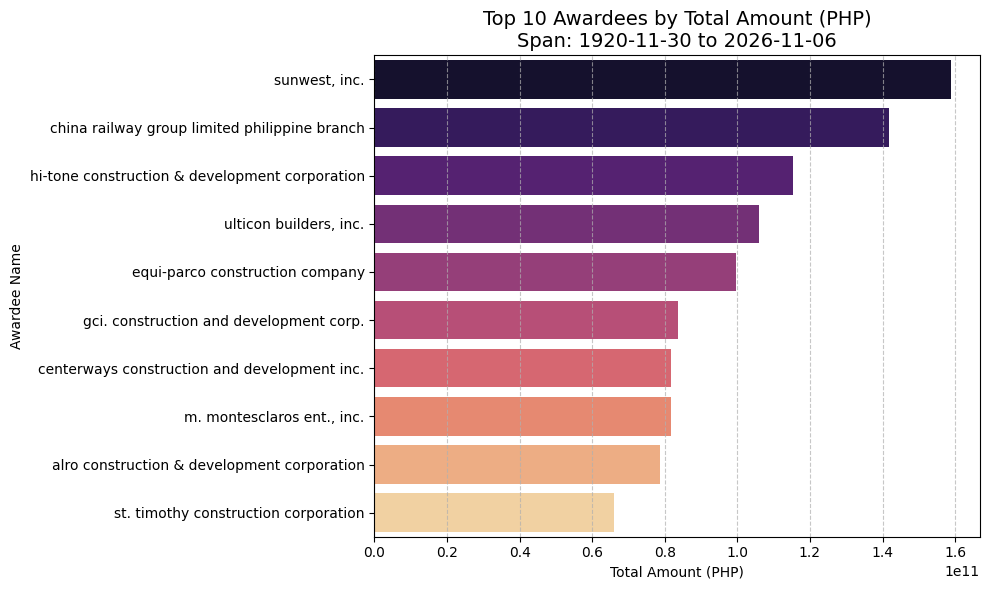

,awardee_name,counts,amount
16132,"sunwest, inc.",1143,1.589111e+11
3541,china railway group limited philippine branch,1,1.417929e+11
7196,hi-tone construction & development corporation,1590,1.152910e+11
16939,"ulticon builders, inc.",589,1.060733e+11
5467,equi-parco construction company,895,9.957535e+10
6369,gci. construction and development corp.,683,8.377179e+10
3423,centerways construction and development inc.,815,8.179665e+10
10402,"m. montesclaros ent., inc.",916,8.160568e+10
1364,alro construction & development corporation,715,7.876150e+10
15956,st. timothy construction corporation,1151,6.599857e+10


In [13]:
get_top_awardees(
    philgeps_df,
    metric='amount',
    business_categories=['construction projects'],
    top_n=10
)

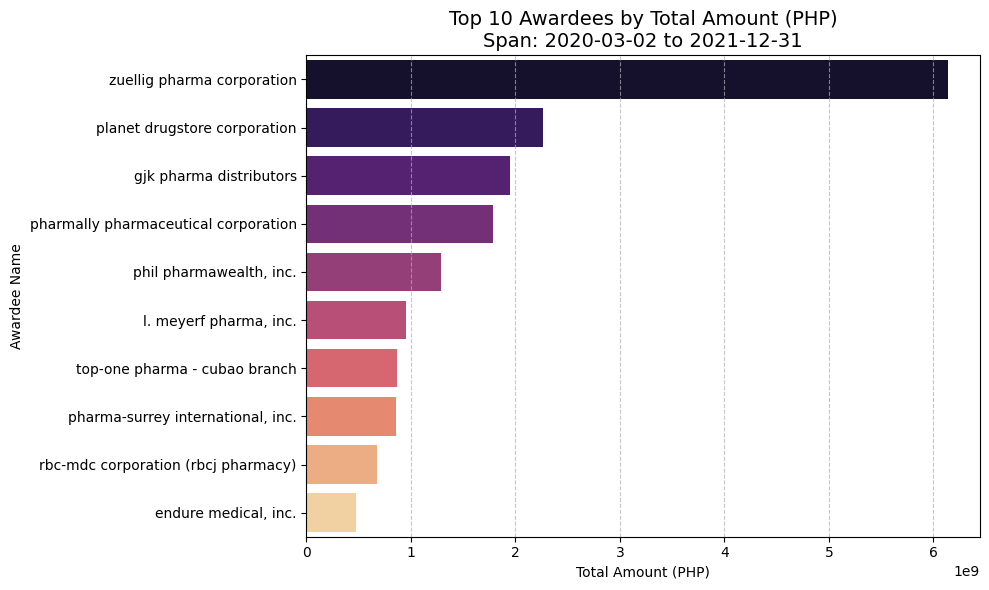

In [14]:
pandemic_start = '2020-03-01'
pandemic_end = '2021-12-31'

# Medical-related categories
# (Note: These are common categories, feel free to add more!)
medical_categories = [
    'medical supplies and equipment',
    'drugs and medicines',
    'hospital / medical equipment services'
]

# Run the analysis
pandemic_winners = get_top_awardees(
    philgeps_df,
    top_n=10,
    metric='amount',
    business_categories=medical_categories,
    start_date=pandemic_start,
    end_date=pandemic_end
)

## Outliers

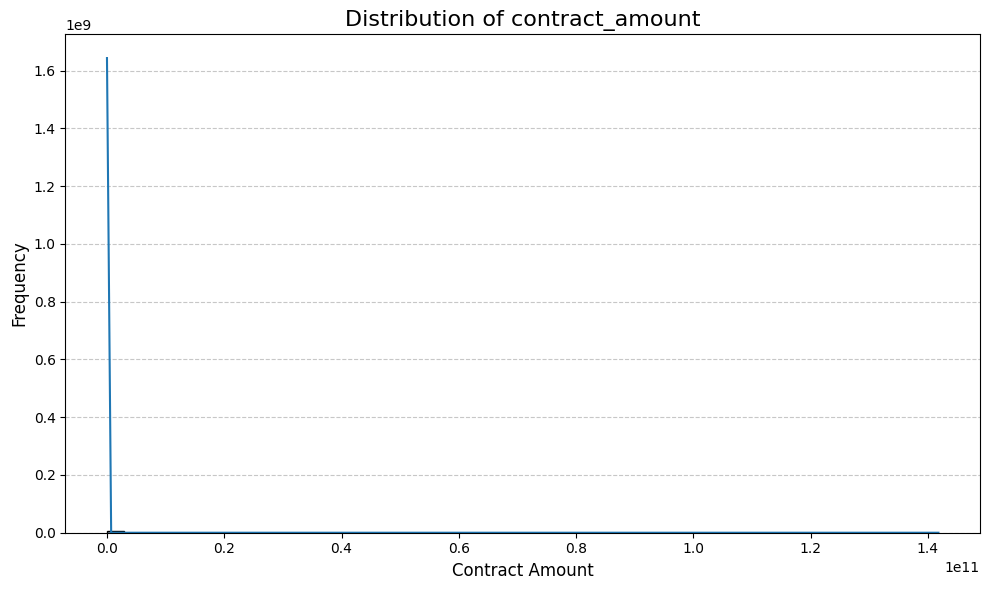

In [15]:
filtered_df = philgeps_df[philgeps_df['contract_amount'] > 0].copy()

plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['contract_amount'], bins=50, kde=True)
plt.title('Distribution of contract_amount', fontsize=16)
plt.xlabel('Contract Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

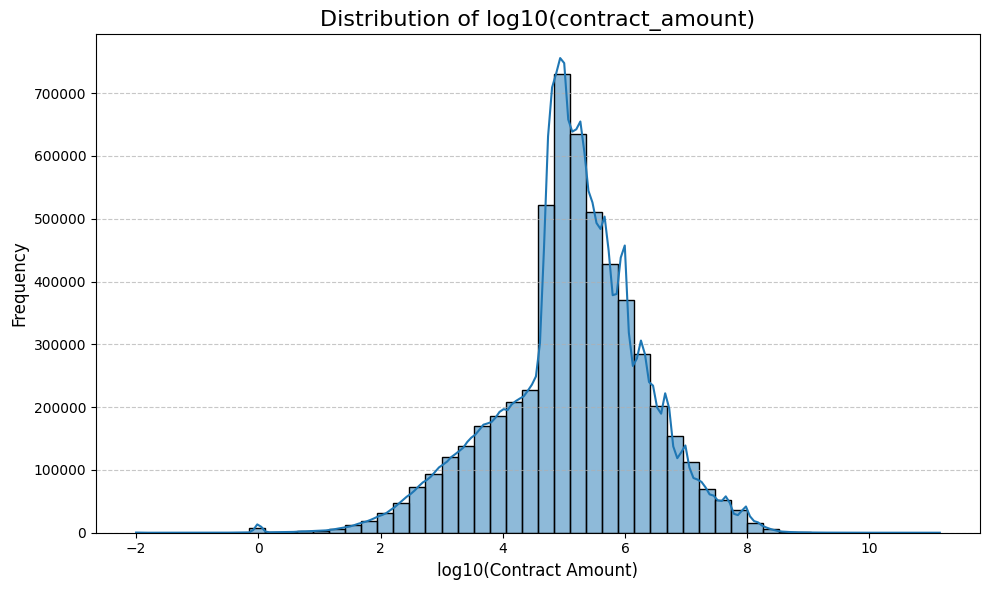

In [16]:
filtered_df = philgeps_df[philgeps_df['contract_amount'] > 0].copy()
filtered_df['log_contract_amount'] = np.log10(filtered_df['contract_amount'])

plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['log_contract_amount'], bins=50, kde=True)
plt.title('Distribution of log10(contract_amount)', fontsize=16)
plt.xlabel('log10(Contract Amount)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
def plot_contract_distribution(df,
                               organization_names=None,
                               awardee_names=None,
                               business_categories=None,
                               areas_of_delivery=None,
                               start_date=None,
                               end_date=None,
                               bins=50):
    """
    Filters PhilGEPS data and plots a log10 distribution of contract amounts.
    """
    filtered_df = df.copy()

    # Date Filtering
    if start_date:
        filtered_df = filtered_df[filtered_df['award_date'] >= pd.to_datetime(start_date)]
    if end_date:
        filtered_df = filtered_df[filtered_df['award_date'] <= pd.to_datetime(end_date)]

    # Categorical Filtering (Case-insensitive approach)
    filter_map = {
        'organization_name': organization_names,
        'awardee_name': awardee_names,
        'business_category': business_categories,
        'area_of_delivery': areas_of_delivery
    }

    for column, filter_list in filter_map.items():
        if filter_list:
            # Convert filter list to lowercase for robust matching
            lower_list = [str(i).lower() for i in filter_list]
            filtered_df = filtered_df[filtered_df[column].str.lower().isin(lower_list)]

    # Data Cleaning for Log Scale
    # Log requires values > 0. We also drop NaNs in contract_amount.
    filtered_df = filtered_df[filtered_df['contract_amount'] > 0].dropna(subset=['contract_amount'])

    if filtered_df.empty:
        print("No data found for the specified filters.")
        return None

    filtered_df['log_contract_amount'] = np.log10(filtered_df['contract_amount'])

    # Visualization
    plt.figure(figsize=(10, 6))
    sns.histplot(filtered_df['log_contract_amount'], bins=bins, kde=True, color='skyblue')

    # Adding descriptive titles based on context
    title = 'Distribution of log10(Contract Amount)'
    if business_categories:
        title += f"\nCategories: {', '.join(business_categories)}"

    plt.title(title, fontsize=14)
    plt.xlabel('Log10 of Contract Amount (PHP)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Add annotation for the "Real Money" scale
    plt.annotate('Scale: 3=1k, 6=1M, 9=1B', xy=(0.02, 0.95), xycoords='axes fraction',
                 fontsize=10, bbox=dict(boxstyle="round", fc="white", ec="gray"))

    plt.tight_layout()
    plt.show()

    return filtered_df

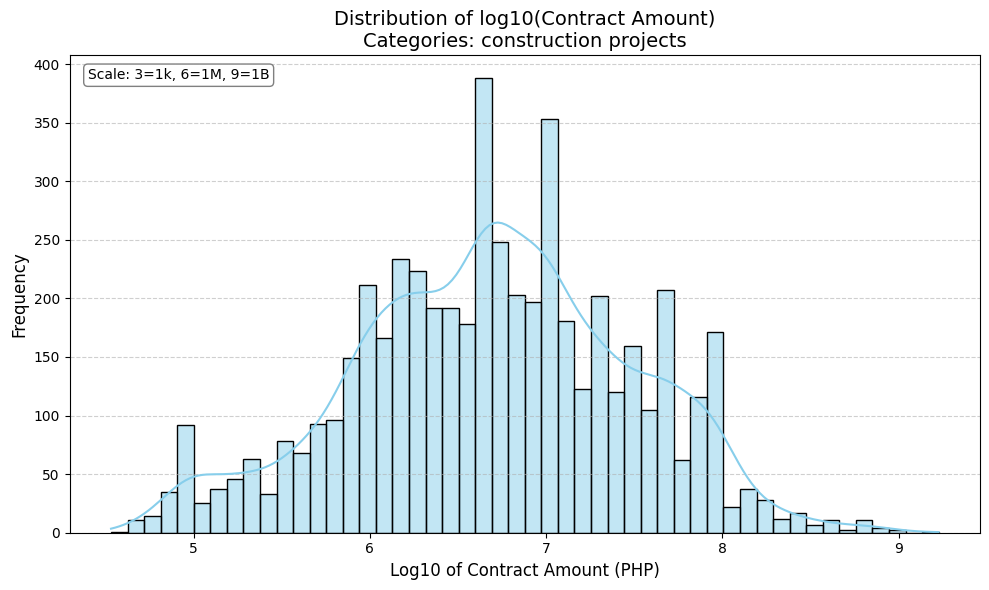

In [18]:
construction_2023 = plot_contract_distribution(
    philgeps_df,
    business_categories=['construction projects'],
    areas_of_delivery=['Metro Manila', 'Rizal'],
    start_date='2023-01-01',
    end_date='2023-12-31'
)

## Time Series Analysis

In [19]:
def explore_time_series(df, time_series_type='amount_sum',
                        organization_names=None,
                        awardee_names=None,
                        business_categories=None,
                        areas_of_delivery=None,
                        time_granularity='monthly',
                        x_lim=None):
    """
    Analyzes and plots time series data for procurement awards based on various filters.

    Args:
        df (pd.DataFrame): The PhilGEPS dataset.
        time_series_type (str): 'counts' for number of awards, 'amount_sum' for total PHP value.
        organization_names (list, optional): Filter by government agencies.
        awardee_names (list, optional): Filter by private companies.
        business_categories (list, optional): Filter by type of industry.
        areas_of_delivery (list, optional): Filter by delivery location.
        time_granularity (str): The time unit for grouping ('daily', 'monthly', 'yearly').
        x_lim (tuple, optional): A tuple of (start_date, end_date) to zoom into the chart.
    """
    filtered_df = df.copy()

    # Ensure award_date is datetime
    filtered_df['award_date'] = pd.to_datetime(filtered_df['award_date'], errors='coerce')
    filtered_df = filtered_df.dropna(subset=['award_date'])

    # Apply Case-Insensitive Filtering
    if organization_names:
        lower_orgs = [n.lower() for n in organization_names]
        filtered_df = filtered_df[filtered_df['organization_name'].str.lower().isin(lower_orgs)]

    if awardee_names:
        lower_awards = [n.lower() for n in awardee_names]
        filtered_df = filtered_df[filtered_df['awardee_name'].str.lower().isin(lower_awards)]

    if business_categories:
        lower_cats = [c.lower() for c in business_categories]
        filtered_df = filtered_df[filtered_df['business_category'].str.lower().isin(lower_cats)]

    if areas_of_delivery:
        lower_areas = [a.lower() for a in areas_of_delivery]
        filtered_df = filtered_df[filtered_df['area_of_delivery'].str.lower().isin(lower_areas)]

    # Check if we have data left after filtering
    if filtered_df.empty:
        print("No data found for those filters. Check your spelling or category names!")
        return None

    # Time Granularity Mapping
    freq_map = {'daily': 'D', 'monthly': 'ME', 'yearly': 'YE'}
    freq = freq_map.get(time_granularity.lower(), 'ME')

    # Aggregation
    if time_series_type == 'counts':
        grouped_data = filtered_df.groupby(pd.Grouper(key='award_date', freq=freq)).size().reset_index(name='value')
    elif time_series_type == 'amount_sum':
        grouped_data = filtered_df.groupby(pd.Grouper(key='award_date', freq=freq))['contract_amount'].sum().reset_index(name='value')

    # Plotting
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='award_date', y='value', data=grouped_data, marker='', color='teal')

    plt.title(f"{time_series_type.replace('_', ' ').title()} Over Time ({time_granularity.title()})", fontsize=15)
    plt.xticks(rotation=45)

    if x_lim:
        plt.xlim(pd.to_datetime(x_lim[0]), pd.to_datetime(x_lim[1]))

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return grouped_data

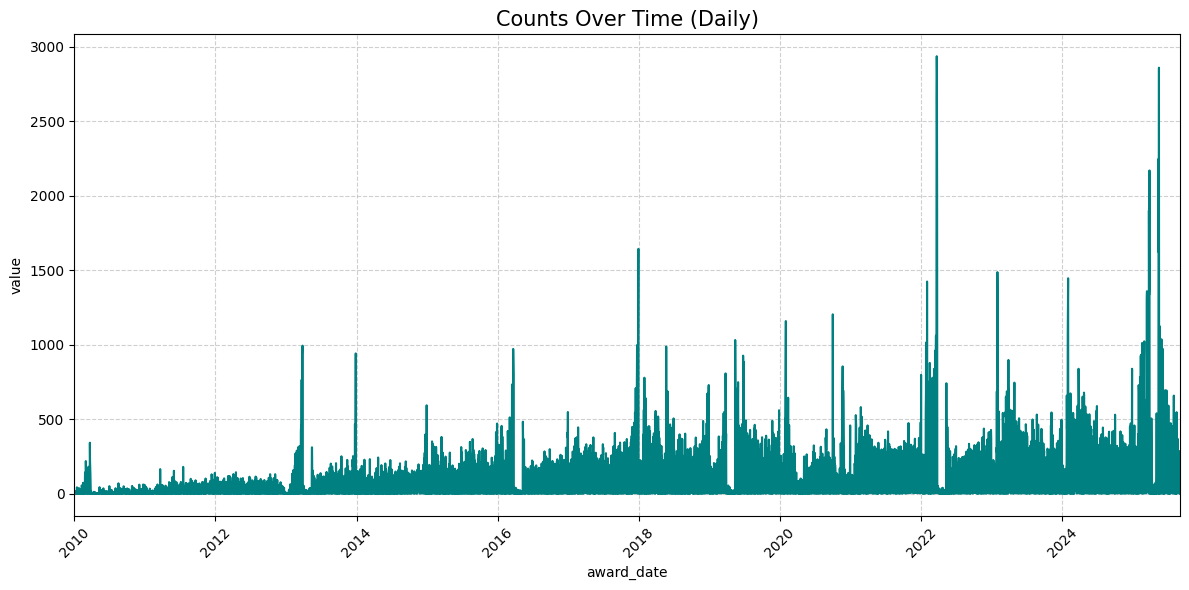

In [20]:
construction_trend = explore_time_series(
    philgeps_df,
    time_series_type='counts',
    business_categories=['construction projects'],
    time_granularity='daily',
    x_lim = ['2010-01-01', '2025-09-01']
)

## Benford's Law

In [21]:
def plot_benford_law(df, awardee_name, to_plot=True):
    """
    Performs Benford's Law analysis on the 'contract_amount' for a specific awardee
    and generates a bar chart comparing actual vs. expected distributions.

    Args:
        df (pd.DataFrame): The input DataFrame containing procurement data.
        awardee_name (str): The name of the awardee to analyze.
    """
    print(f"Benford's Law analysis for awardee: {awardee_name}")

    # Filter the DataFrame for the specific awardee
    awardee_df = df[df['awardee_name'] == awardee_name].copy()

    if awardee_df.empty:
        print(f"No data found for awardee: {awardee_name}")
        return

    # Extract 'contract_amount', drop NaNs, and convert to absolute values
    amounts = awardee_df['contract_amount']

    if amounts.empty:
        print(f"No valid contract amounts found for awardee: {awardee_name}")
        return

    first_digits = amounts.astype(str).str[0].astype(int)

    # Filter out any non-Benford digits (if a number started with 0 or a decimal)
    first_digits = first_digits[(first_digits >= 1) & (first_digits <= 9)]

    if first_digits.empty:
        print(f"No first digits (1-9) could be extracted from contract amounts for awardee: {awardee_name}")
        return

    actual_distribution = first_digits.value_counts(normalize=True).sort_index()

    # Benford's Law probabilities for digits 1 through 9
    expected_benford = {d: np.log10(1 + 1/d) for d in range(1, 10)}
    expected_distribution = pd.Series(expected_benford)

    comparison_df = pd.DataFrame({
        'Actual': actual_distribution,
        'Expected': expected_distribution
    }).fillna(0) # Fill NaN for digits not present in actual_distribution

    # Ensure all digits from 1 to 9 are present in the index for plotting consistency
    all_digits = pd.RangeIndex(start=1, stop=10)
    comparison_df = comparison_df.reindex(all_digits, fill_value=0)

    # Generate bar plot
    if to_plot:
        fig, ax = plt.subplots(figsize=(7, 3))

        comparison_df.plot(kind='bar', ax=ax, width=0.8, color=['skyblue', 'lightcoral'])

        ax.set_title(f"Benford's Law Analysis for {awardee_name}", fontsize=16)
        ax.set_xlabel('First Digit', fontsize=12)
        ax.set_ylabel('Proportion', fontsize=12)
        ax.set_xticks(range(len(comparison_df.index)))
        ax.set_xticklabels(comparison_df.index, rotation=0)
        ax.legend(title='Distribution')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    return comparison_df

Benford's Law analysis for awardee: petron corporation


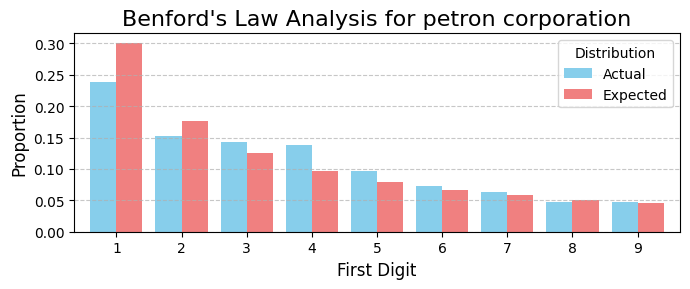

Benford's Law analysis for awardee: sunwest, inc.


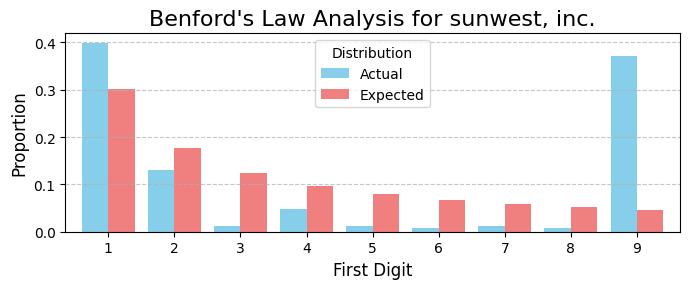

In [22]:
_ = plot_benford_law(philgeps_df, 'petron corporation')
_ = plot_benford_law(philgeps_df, 'sunwest, inc.')

Benford's Law analysis for awardee: petron corporation


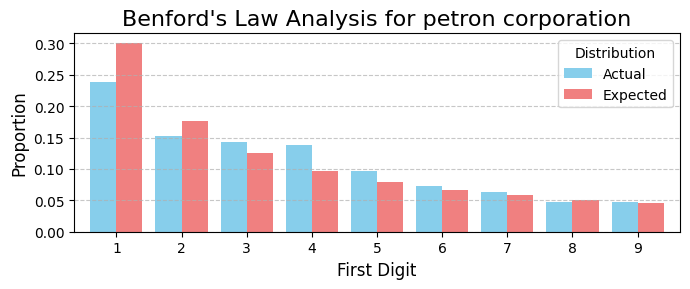

Benford's Law analysis for awardee: sunwest, inc.


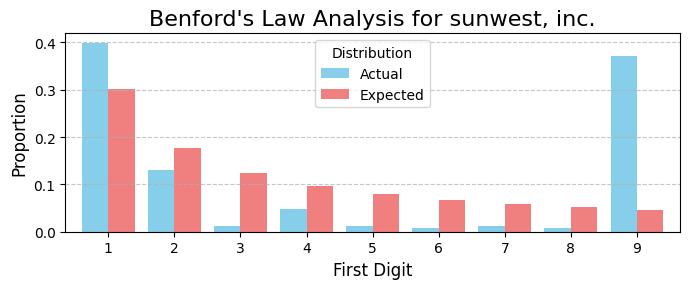

Benford's Law analysis for awardee: hi-tone construction & development corporation


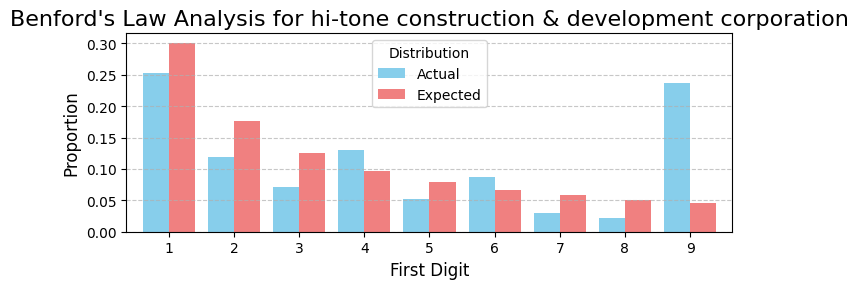

Benford's Law analysis for awardee: ulticon builders, inc.


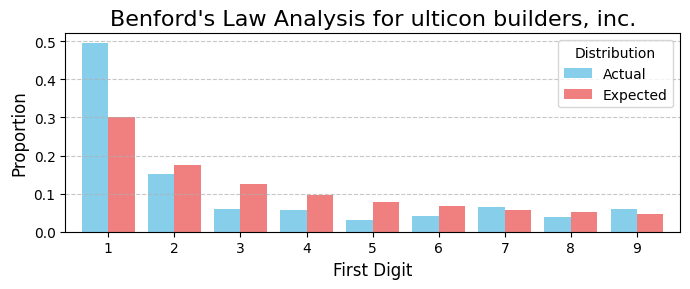

Benford's Law analysis for awardee: equi-parco construction company


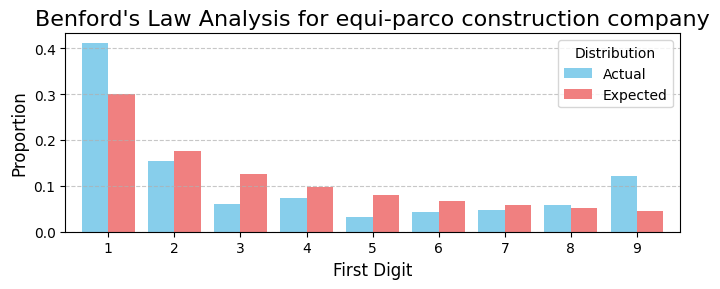

Benford's Law analysis for awardee: gci. construction and development corp.


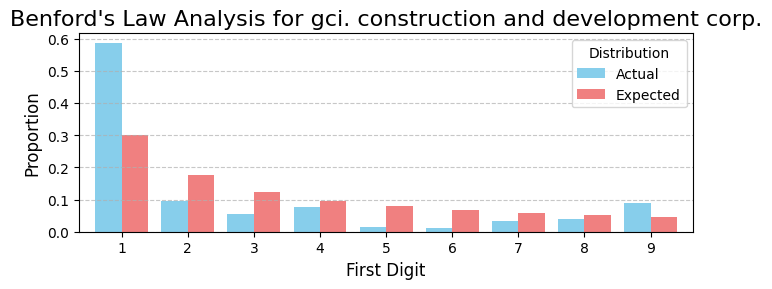

Benford's Law analysis for awardee: m. montesclaros ent., inc.


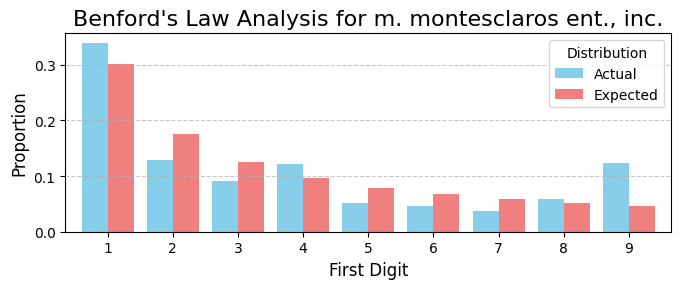

Benford's Law analysis for awardee: centerways construction and development inc.


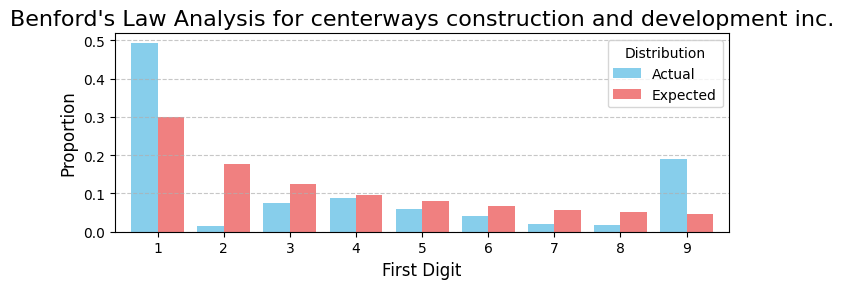

Benford's Law analysis for awardee: alro construction & development corporation


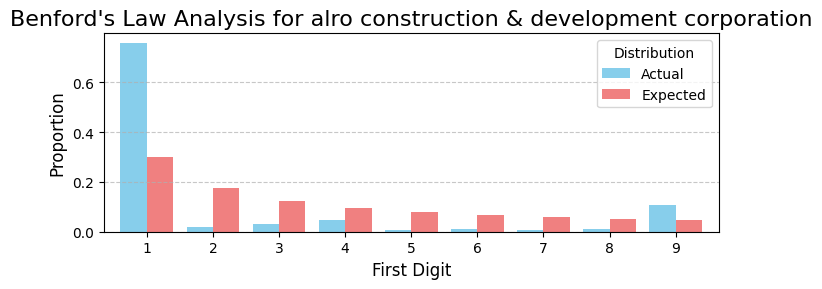

Benford's Law analysis for awardee: st. timothy construction corporation


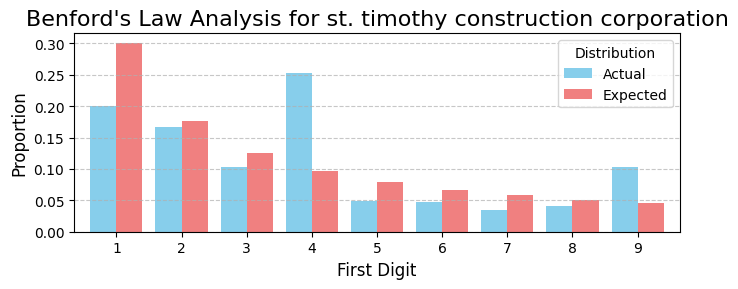

Benford's Law analysis for awardee: ibc international builders corporation


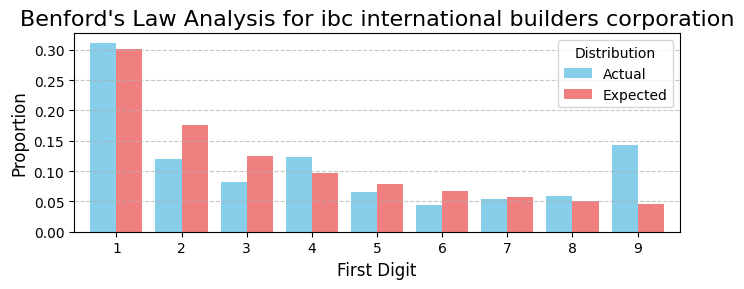

Benford's Law analysis for awardee: mg samidan construction


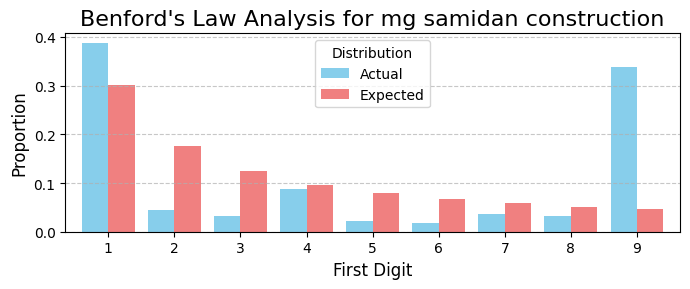

Benford's Law analysis for awardee: legacy construction corporation


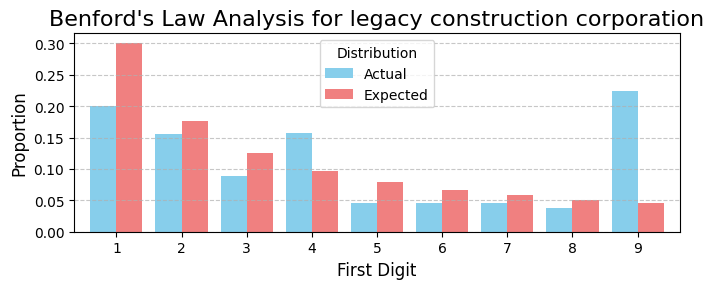

Benford's Law analysis for awardee: brentmin roofing enterprise


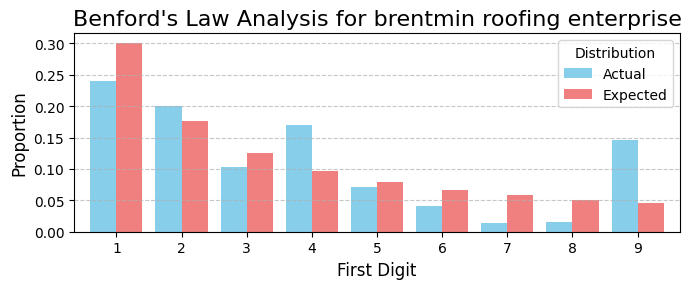

Benford's Law analysis for awardee: bicol goldrock construction corporation


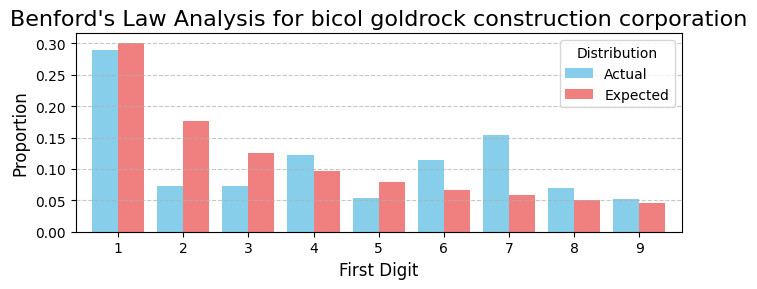

Benford's Law analysis for awardee: vicente t. lao construction


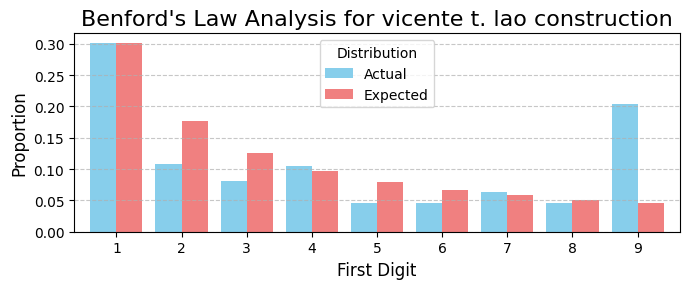

Benford's Law analysis for awardee: aremar construction corporation


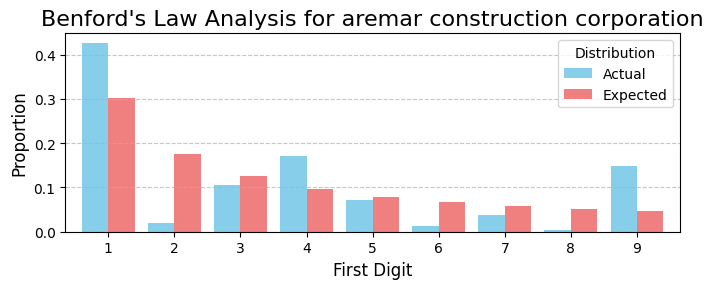

Benford's Law analysis for awardee: hgg builders and supply


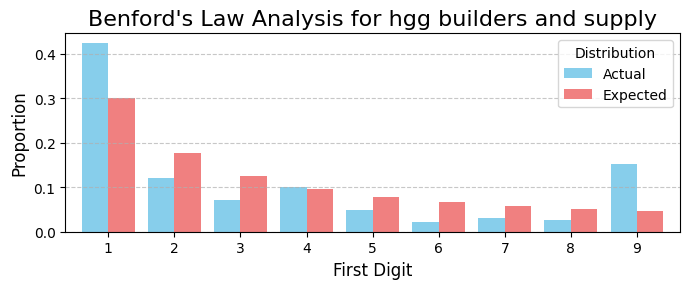

Benford's Law analysis for awardee: ffjj construction


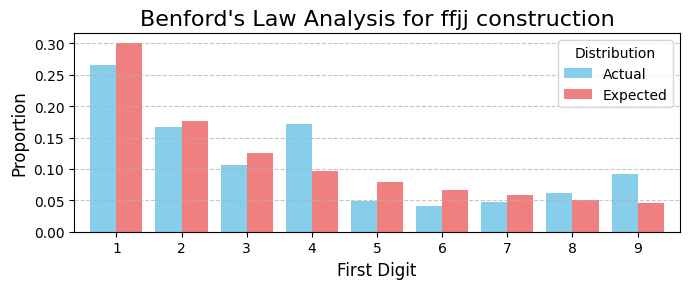

In [23]:
awardee_list = [
    "petron corporation",
    "sunwest, inc.",
    "hi-tone construction & development corporation",
    "ulticon builders, inc.",
    "equi-parco construction company",
    "gci. construction and development corp.",
    "m. montesclaros ent., inc.",
    "centerways construction and development inc.",
    "alro construction & development corporation",
    "st. timothy construction corporation",
    "ibc international builders corporation",
    "mg samidan construction",
    "legacy construction corporation",
    "brentmin roofing enterprise",
    "bicol goldrock construction corporation",
    "vicente t. lao construction",
    "aremar construction corporation",
    "hgg builders and supply",
    "ffjj construction"
]
top_awardees = pd.DataFrame(awardee_list, columns=['awardee'])

top_awardees_benford = []
for awardee in top_awardees['awardee']:
    comparison_df = plot_benford_law(philgeps_df, awardee)
    top_awardees_benford.append(comparison_df)

## Day of the Week Awarding

In [24]:
def analyze_day_of_week_awards(df, organization_names=None,
                               awardee_names=None,
                               business_categories=None,
                               areas_of_delivery=None):
    """
    Analyzes and visualizes the distribution of awards by day of the week.
    Helps spot suspicious weekend activity.
    """
    filtered_df = df.copy()

    # Apply Filtering Logic (consistent with previous tools)
    if organization_names:
        filtered_df = filtered_df[filtered_df['organization_name'].isin([n.lower() for n in organization_names])]
    if awardee_names:
        filtered_df = filtered_df[filtered_df['awardee_name'].isin([n.lower() for n in awardee_names])]
    if business_categories:
        filtered_df = filtered_df[filtered_df['business_category'].isin([c.lower() for c in business_categories])]
    if areas_of_delivery:
        filtered_df = filtered_df[filtered_df['area_of_delivery'].isin([a.lower() for a in areas_of_delivery])]

    if filtered_df.empty:
        print("No data found after applying filters.")
        return

    # Extract and Sort Days
    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    filtered_df['day_of_week'] = pd.Categorical(filtered_df['award_date'].dt.day_name(),
                                                categories=day_names,
                                                ordered=True)

    # Create Daily Summary
    daily_summary = filtered_df.groupby('day_of_week', observed=False).agg(
        num_awards=('award_date', 'count'),
        total_contract_amount=('contract_amount', 'sum')
    ).reset_index()

    total_awards_overall = daily_summary['num_awards'].sum()
    daily_summary['percentage_awards'] = (daily_summary['num_awards'] / total_awards_overall) * 100

    # Print Summary Table
    print("\n--- Daily Award Statistics ---")
    print(daily_summary)
    print(f"\nTotal Awards Analyzed: {total_awards_overall:,}")

    # Visualization
    plt.figure(figsize=(10, 6))
    sns.barplot(x='day_of_week', y='percentage_awards', data=daily_summary,
                hue='day_of_week', palette='viridis', legend=False)

    # Dynamic Title
    plot_title = 'Percentage of Awards by Day of the Week'
    if organization_names:
        plot_title += f"\n(Agency: {', '.join(organization_names[:2])})"

    plt.title(plot_title, fontsize=16)
    plt.xlabel('Day of the Week', fontsize=12)
    plt.ylabel('Percentage (%) of Total Awards', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, max(daily_summary['percentage_awards']) + 5)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return daily_summary


--- Daily Award Statistics ---
  day_of_week  num_awards  total_contract_amount  percentage_awards
0      Monday     1104299           3.445786e+12          20.147177
1     Tuesday     1180436           3.478496e+12          21.536244
2   Wednesday     1074134           3.229245e+12          19.596837
3    Thursday     1003633           3.325513e+12          18.310595
4      Friday     1001393           3.121420e+12          18.269728
5    Saturday       80799           1.153414e+11           1.474122
6      Sunday       36466           1.185485e+11           0.665297

Total Awards Analyzed: 5,481,160


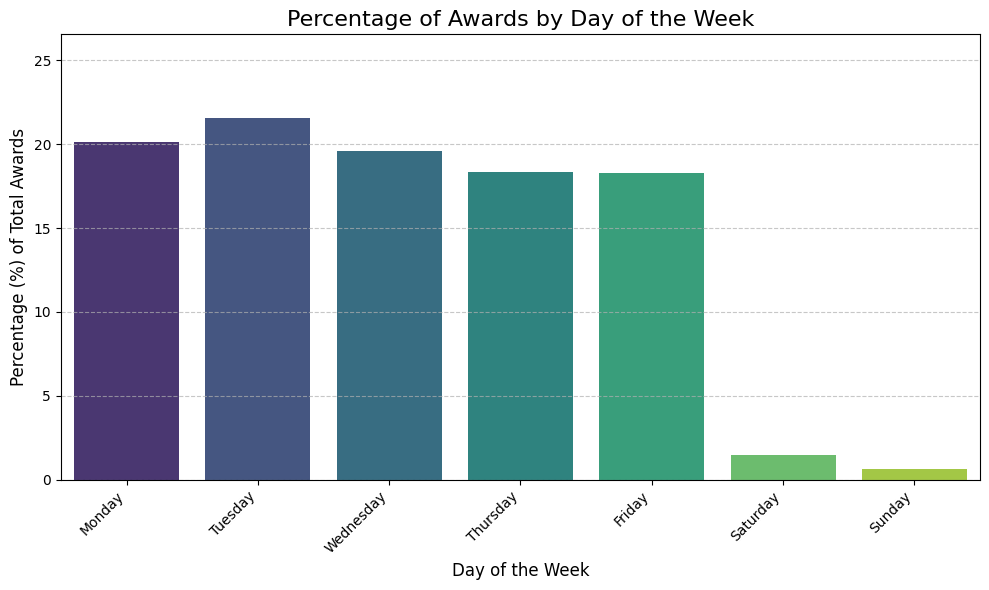

In [25]:
_ = analyze_day_of_week_awards(
    df=philgeps_df,
    organization_names=None,
    awardee_names=None,
    business_categories=None
)